## 1. Instalar e importar bibliotecas

In [22]:
!pip -q install rasterio scikit-image scikit-learn scipy

from pathlib import Path
import re
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from skimage.morphology import remove_small_objects, remove_small_holes, binary_dilation
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from scipy.ndimage import distance_transform_edt, uniform_filter
from sklearn.tree import plot_tree


## 2. Configurações

In [23]:
BASE_DIR = Path(os.getcwd())
DATA_DIR = Path(BASE_DIR, 'data', 'NTL_LITORAL_SC', 'QGIS_LITORAL', 'RASTER', 'NTL_LITORAL')
RESULTADOS_DIR = Path(BASE_DIR, 'resultados')
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

MOSTRAR_DETALHES = False

if MOSTRAR_DETALHES:
    print("Pasta de dados:", DATA_DIR)
    print("Pasta de resultados:", RESULTADOS_DIR)

## 3. Função auxiliar para salvar arquivos CSV

In [24]:
def salvar_arquivo_csv(tabela, nome_arquivo):
    caminho_arquivo = RESULTADOS_DIR / f"{nome_arquivo}.csv"
    tabela.to_csv(caminho_arquivo, index=False)
    if MOSTRAR_DETALHES:
        print(f"Arquivo salvo: {caminho_arquivo}")

## 4. Listar os arquivos `.tif`

In [25]:
padrao_nome_arquivo = re.compile(
    r"VIIRS_NTL_MedianaMensal_(?P<regiao>.+?)_(?P<ano>\d{4})_(?P<mes>\d{2})_reprojetada.*\.tif$"
)

linhas_arquivos = []

for caminho_imagem in DATA_DIR.rglob("*.tif"):
    resultado_nome = padrao_nome_arquivo.search(caminho_imagem.name)

    if resultado_nome is None:
        continue

    regiao = resultado_nome.group("regiao")
    ano = int(resultado_nome.group("ano"))
    mes = int(resultado_nome.group("mes"))

    linhas_arquivos.append({
        "regiao": regiao,
        "ano": ano,
        "mes": mes,
        "data": pd.Timestamp(year=ano, month=mes, day=1),
        "caminho_tif": str(caminho_imagem),
        "possui_aux_xml": caminho_imagem.with_name(caminho_imagem.name + ".aux.xml").exists()
    })

tabela_arquivos = pd.DataFrame(linhas_arquivos)

tabela_arquivos = tabela_arquivos.sort_values(["regiao", "ano", "mes"]).reset_index(drop=True)

if MOSTRAR_DETALHES:
    display(tabela_arquivos.head())
    print("Total de imagens encontradas:", len(tabela_arquivos))

## 5. Funções principais

In [26]:

# Função para pegar os dados de uma imagem
def ler_imagem_luzes(caminho_tif):
    with rasterio.open(caminho_tif) as imagem_raster:
        imagem_luzes = imagem_raster.read(1).astype("float32")
        valor_sem_dado = imagem_raster.nodata
        transformacao_espacial = imagem_raster.transform
        sistema_referencia = imagem_raster.crs

    mascara_valida = np.isfinite(imagem_luzes)

    if valor_sem_dado is not None:
        mascara_valida = mascara_valida & (imagem_luzes != valor_sem_dado)

    imagem_luzes[~mascara_valida] = np.nan
    return imagem_luzes, transformacao_espacial, sistema_referencia

# Limpa valores extremos e normaliza a imagem de forma logaritmica para visualização
def normalizar_para_visualizacao(imagem_luzes, percentil_maximo=99):
    imagem_visual = imagem_luzes.copy()
    valores_validos = imagem_visual[np.isfinite(imagem_visual)]

    limite_superior = np.nanpercentile(valores_validos, percentil_maximo)
    imagem_visual = np.clip(imagem_visual, 0, limite_superior)
    imagem_visual = np.log1p(imagem_visual)
    return imagem_visual


# Calcula um valor para usar de threshold usando as amostras de uma regiao (não pega todos os valores, só uma parte para agilizar)
def calcular_threshold_regiao(tabela_arquivos_regiao, percentil_threshold=75, limite_amostras_por_imagem=50000):
    amostras_luzes = []

    for linha in tabela_arquivos_regiao.itertuples():
        imagem_luzes, _, _ = ler_imagem_luzes(linha.caminho_tif)
        valores_validos = imagem_luzes[np.isfinite(imagem_luzes)] # Remove NaN, inf, -inf
        valores_positivos = valores_validos[valores_validos > 0] # Remove < 0

        if len(valores_positivos) > limite_amostras_por_imagem:
            indices_amostra = np.random.choice(
                len(valores_positivos),
                size=limite_amostras_por_imagem,
                replace=False
            )
            valores_positivos = valores_positivos[indices_amostra]

        amostras_luzes.append(valores_positivos)

    if len(amostras_luzes) == 0:
        return 0.0

    valores_regiao = np.concatenate(amostras_luzes)
    return float(np.nanpercentile(valores_regiao, percentil_threshold))

# A partir de um threshold gera um array com binário: Pixel iluminado / Apagado
def criar_mascara_area_iluminada(imagem_luzes, threshold_luz):
    mascara_area_iluminada = np.zeros(imagem_luzes.shape, dtype=bool)
    mascara_valida = np.isfinite(imagem_luzes)

    mascara_area_iluminada[mascara_valida] = imagem_luzes[mascara_valida] >= threshold_luz
    mascara_area_iluminada = remove_small_objects(mascara_area_iluminada, min_size=9)
    mascara_area_iluminada = remove_small_holes(mascara_area_iluminada, area_threshold=9)

    return mascara_area_iluminada

# transformacao_espacial vem do .tif e tem informações sobre tamanho do pixel e posição na imagem, o sistema_referencia traz
# informações sobre o sistema geográfico usado. Retorna o valor em km² que um pixel representa
def calcular_area_pixel_km2(transformacao_espacial, sistema_referencia):
    if sistema_referencia is not None and sistema_referencia.is_projected:
        area_pixel_m2 = abs(transformacao_espacial.a * transformacao_espacial.e)
        return area_pixel_m2 / 1_000_000

    return 1.0

# Gera o resumo das funções anteriores. Retorna um dicionario com as informações
def extrair_metricas_area_iluminada(imagem_luzes, mascara_area_iluminada, transformacao_espacial, sistema_referencia):
    quantidade_pixels_validos = int(np.isfinite(imagem_luzes).sum())
    quantidade_pixels_iluminados = int(mascara_area_iluminada.sum())
    area_pixel_km2 = calcular_area_pixel_km2(transformacao_espacial, sistema_referencia)

    area_iluminada_km2 = quantidade_pixels_iluminados * area_pixel_km2
    percentual_area_iluminada = (
        quantidade_pixels_iluminados / quantidade_pixels_validos
        if quantidade_pixels_validos > 0 else np.nan
    )

    if quantidade_pixels_iluminados > 0:
        media_luz_area_iluminada = float(np.nanmean(imagem_luzes[mascara_area_iluminada]))
    else:
        media_luz_area_iluminada = np.nan

    return {
        "pixels_validos": quantidade_pixels_validos,
        "pixels_iluminados": quantidade_pixels_iluminados,
        "area_iluminada_km2": area_iluminada_km2,
        "percentual_area_iluminada": percentual_area_iluminada,
        "media_luz_area_iluminada": media_luz_area_iluminada,
        "media_luz_total": float(np.nanmean(imagem_luzes))
    }

## 6. Calcular um threshold para cada região

In [27]:
PERCENTIL_THRESHOLD = 75

thresholdes_por_regiao = {}

for regiao in sorted(tabela_arquivos["regiao"].unique()):
    tabela_regiao = tabela_arquivos[tabela_arquivos["regiao"] == regiao]
    threshold_regiao = calcular_threshold_regiao(tabela_regiao, percentil_threshold=PERCENTIL_THRESHOLD)
    thresholdes_por_regiao[regiao] = threshold_regiao
    print(f"{regiao}: threshold = {threshold_regiao:.4f}")

Blumenau: threshold = 8.4070
Criciuma: threshold = 2.1006
Florianopolis: threshold = 5.2300
Joinville: threshold = 1.9122


## 7. Visualizar uma imagem de exemplo

C:\Users\thomh\AppData\Local\Temp\ipykernel_10540\2405432127.py:59: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_area_iluminada = remove_small_objects(mascara_area_iluminada, min_size=9)
C:\Users\thomh\AppData\Local\Temp\ipykernel_10540\2405432127.py:60: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  

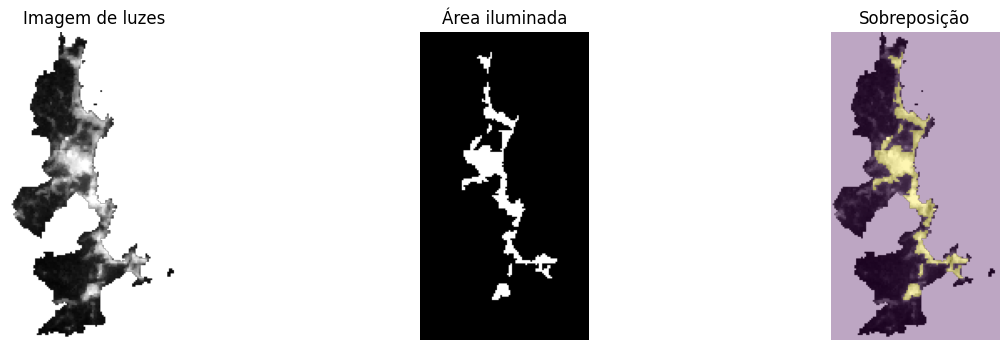

In [28]:
# Mostra
# 1- Imagem original
# 2- Imagem binarizada
# 3- Sobreposição da original + binarizada

exemplo_arquivo = tabela_arquivos.iloc[0]

imagem_luzes, transformacao_espacial, sistema_referencia = ler_imagem_luzes(exemplo_arquivo.caminho_tif)
imagem_visual = normalizar_para_visualizacao(imagem_luzes)
mascara_area_iluminada = criar_mascara_area_iluminada(
    imagem_luzes,
    threshold_luz=thresholdes_por_regiao[exemplo_arquivo.regiao]
)

if MOSTRAR_DETALHES:
    print("Região:", exemplo_arquivo.regiao)
    print("Data:", exemplo_arquivo.data.date())
    print("Threshold usado:", thresholdes_por_regiao[exemplo_arquivo.regiao])

figura, eixos = plt.subplots(1, 3, figsize=(15, 4))

eixos[0].imshow(imagem_visual, cmap="gray")
eixos[0].set_title("Imagem de luzes")

eixos[1].imshow(mascara_area_iluminada, cmap="gray")
eixos[1].set_title("Área iluminada")

eixos[2].imshow(imagem_visual, cmap="gray")
eixos[2].imshow(mascara_area_iluminada, alpha=0.35)
eixos[2].set_title("Sobreposição")

for eixo in eixos:
    eixo.axis("off")

plt.show()

## 8. Processar todas as imagens

In [29]:
linhas_metricas = []
total_imagens = len(tabela_arquivos)

for numero_linha, linha in enumerate(tabela_arquivos.itertuples(), start=1):
    porcentagem = 100 * numero_linha / total_imagens
    if MOSTRAR_DETALHES:
        print(f"Processando {numero_linha}/{total_imagens} ({porcentagem:.1f}%): {linha.regiao} {linha.ano}-{linha.mes:02d}")

    imagem_luzes, transformacao_espacial, sistema_referencia = ler_imagem_luzes(linha.caminho_tif)
    threshold_luz = thresholdes_por_regiao[linha.regiao]
    mascara_area_iluminada = criar_mascara_area_iluminada(imagem_luzes, threshold_luz)
    metricas_area = extrair_metricas_area_iluminada(
        imagem_luzes,
        mascara_area_iluminada,
        transformacao_espacial,
        sistema_referencia
    )

    linhas_metricas.append({
        "regiao": linha.regiao,
        "ano": linha.ano,
        "mes": linha.mes,
        "data": linha.data,
        "threshold_luz": threshold_luz,
        **metricas_area
    })

tabela_metricas = pd.DataFrame(linhas_metricas)
tabela_metricas = tabela_metricas.sort_values(["regiao", "data"]).reset_index(drop=True)

display(tabela_metricas.head())

salvar_arquivo_csv(tabela_metricas, "metricas_area_iluminada")

C:\Users\thomh\AppData\Local\Temp\ipykernel_10540\2405432127.py:59: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_area_iluminada = remove_small_objects(mascara_area_iluminada, min_size=9)
C:\Users\thomh\AppData\Local\Temp\ipykernel_10540\2405432127.py:60: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  

,regiao,ano,mes,data,threshold_luz,pixels_validos,pixels_iluminados,area_iluminada_km2,percentual_area_iluminada,media_luz_area_iluminada,media_luz_total
0,Blumenau,2015,1,2015-01-01,8.406987,5608,1170,275.000216,0.208631,73.018913,16.565205
1,Blumenau,2015,2,2015-02-01,8.406987,5608,1197,281.346375,0.213445,37.494766,9.290390
2,Blumenau,2015,3,2015-03-01,8.406987,5608,1202,282.521589,0.214337,36.583309,9.261672
3,Blumenau,2015,4,2015-04-01,8.406987,5608,1206,283.461761,0.215050,37.555481,9.863873
4,Blumenau,2015,5,2015-05-01,8.406987,5608,1161,272.884830,0.207026,36.967052,9.329413


## 9. Tratamento de outliers

In [30]:
# Faz a limpeza de ruídos nas imagens
def tratar_outliers_area_iluminada(tabela_metricas, janela_mediana=5, fator_limite=3.5):
    tabelas_tratadas = []

    for regiao in sorted(tabela_metricas["regiao"].unique()):
        dados_regiao = tabela_metricas[tabela_metricas["regiao"] == regiao].copy()
        dados_regiao = dados_regiao.sort_values("data").reset_index(drop=True)

        serie_area = dados_regiao["area_iluminada_km2"].astype(float)

        mediana_movel = serie_area.rolling(
            window=janela_mediana,
            center=True,
            min_periods=3
        ).median()
        mediana_movel = mediana_movel.bfill().ffill()

        diferenca_mediana = (serie_area - mediana_movel).abs()
        desvio_mediano = np.nanmedian(diferenca_mediana)

        dados_regiao["area_iluminada_km2_original"] = serie_area
        dados_regiao["mediana_movel_area_km2"] = mediana_movel
        dados_regiao["diferenca_mediana_movel"] = diferenca_mediana

        if desvio_mediano == 0 or np.isnan(desvio_mediano):
            dados_regiao["limite_outlier_km2"] = np.nan
            dados_regiao["area_outlier"] = False
            dados_regiao["area_iluminada_km2_limpa"] = serie_area
        else:
            limite_outlier = fator_limite * 1.4826 * desvio_mediano
            dados_regiao["limite_outlier_km2"] = limite_outlier
            dados_regiao["area_outlier"] = diferenca_mediana > limite_outlier
            dados_regiao["area_iluminada_km2_limpa"] = serie_area

            dados_regiao.loc[
                dados_regiao["area_outlier"],
                "area_iluminada_km2_limpa"
            ] = np.nan

            dados_regiao["area_iluminada_km2_limpa"] = (
                dados_regiao["area_iluminada_km2_limpa"]
                .interpolate()
                .bfill()
                .ffill()
            )

        tabelas_tratadas.append(dados_regiao)

    return pd.concat(tabelas_tratadas, ignore_index=True)


# Aplica o tratamento de outliers
tabela_metricas_com_outliers = tratar_outliers_area_iluminada(tabela_metricas)

# A tabela abaixo será usada nas etapas de gráfico, validação e previsão
# Ela mantém as mesmas colunas principais, mas substitui area_iluminada_km2 pela versão tratada
tabela_metricas_modelo = tabela_metricas_com_outliers.copy()
tabela_metricas_modelo["area_iluminada_km2"] = tabela_metricas_modelo["area_iluminada_km2_limpa"]

resumo_outliers = (
    tabela_metricas_com_outliers
    .groupby("regiao")["area_outlier"]
    .sum()
    .reset_index()
    .rename(columns={"area_outlier": "quantidade_outliers"})
)

if MOSTRAR_DETALHES:
    display(resumo_outliers)

    display(
        tabela_metricas_com_outliers[
            tabela_metricas_com_outliers["area_outlier"]
        ][[
            "regiao",
            "data",
            "area_iluminada_km2_original",
            "area_iluminada_km2_limpa",
            "mediana_movel_area_km2"
        ]]
    )

salvar_arquivo_csv(tabela_metricas_modelo, "metricas_area_iluminada_tratada")

## 10. Gráfico da área iluminada ao longo do tempo

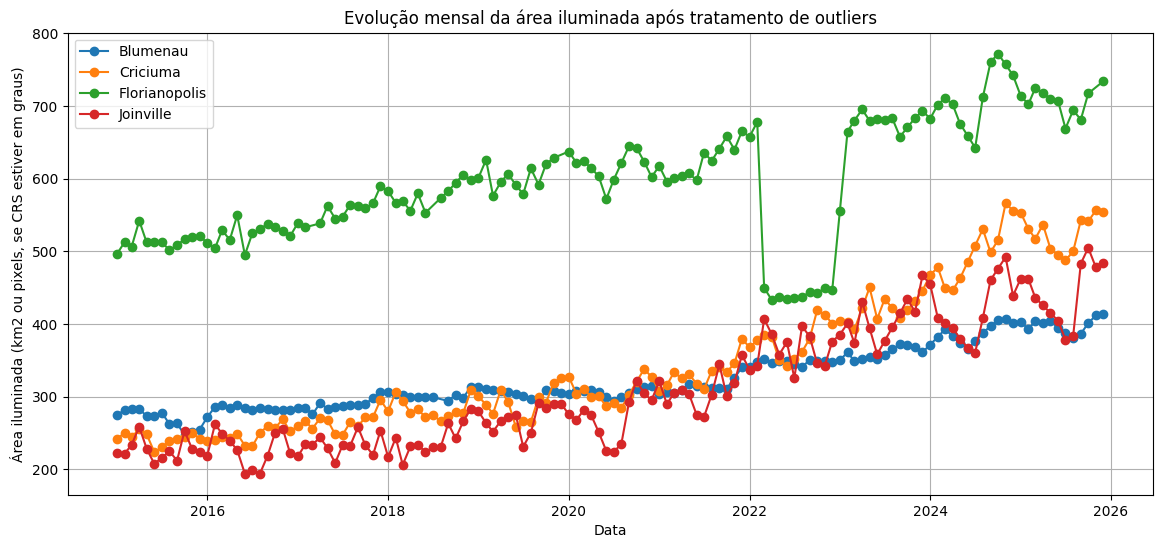

In [31]:
plt.figure(figsize=(14, 6))

for regiao in sorted(tabela_metricas_modelo["regiao"].unique()):
    dados_regiao = tabela_metricas_modelo[tabela_metricas_modelo["regiao"] == regiao]
    plt.plot(dados_regiao["data"], dados_regiao["area_iluminada_km2"], marker="o", label=regiao)

plt.title("Evolução mensal da área iluminada após tratamento de outliers")
plt.xlabel("Data")
plt.ylabel("Área iluminada (km2 ou pixels, se CRS estiver em graus)")
plt.legend()
plt.grid(True)
plt.show()

## 11. Previsão com MLPRegressor


In [32]:
COLUNAS_ENTRADA = [
    "indice_mes",
    "sazonalidade_seno",
    "sazonalidade_cosseno",
    "area_1_mes_atras",
    "area_2_meses_atras",
    "area_12_meses_atras"
]

COLUNA_ALVO = "area_iluminada_km2"

# Gera variáveis temporais e features de atraso para o MLPRegressor
# O seno e o cosseno representam a sazonalidade dos meses
# As áreas de meses anteriores ajudam o modelo a considerar a progressão temporal da área iluminada
def adicionar_features_atraso_regiao(dados_regiao):
    dados_regiao = dados_regiao.sort_values("data").copy()

    ano_inicial = dados_regiao["ano"].min()
    dados_regiao["indice_mes"] = (dados_regiao["ano"] - ano_inicial) * 12 + dados_regiao["mes"]
    dados_regiao["sazonalidade_seno"] = np.sin(2 * np.pi * dados_regiao["mes"] / 12)
    dados_regiao["sazonalidade_cosseno"] = np.cos(2 * np.pi * dados_regiao["mes"] / 12)

    dados_regiao["area_1_mes_atras"] = dados_regiao["area_iluminada_km2"].shift(1)
    dados_regiao["area_2_meses_atras"] = dados_regiao["area_iluminada_km2"].shift(2)
    dados_regiao["area_12_meses_atras"] = dados_regiao["area_iluminada_km2"].shift(12)

    return dados_regiao

# Retorna uma rede neural simples treinada para uma região
# O TransformedTargetRegressor normaliza também o alvo, reduzindo o risco de explosão da previsão
def treinar_modelo_regiao(dados_regiao):
    dados_modelo = adicionar_features_atraso_regiao(dados_regiao)
    dados_modelo = dados_modelo.dropna(subset=COLUNAS_ENTRADA + [COLUNA_ALVO])

    if len(dados_modelo) < 24:
        return None

    modelo_base = make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(16,),
            activation="relu",
            solver="adam",
            alpha=0.01,
            learning_rate_init=0.001,
            max_iter=3000,
            early_stopping=True,
            random_state=42
        )
    )

    modelo_mlp = TransformedTargetRegressor(
        regressor=modelo_base,
        transformer=StandardScaler()
    )

    modelo_mlp.fit(
        dados_modelo[COLUNAS_ENTRADA],
        dados_modelo[COLUNA_ALVO]
    )

    return modelo_mlp


# Pega os valores temporais da região
# Treina o MLPRegressor
# Faz uma previsão para os x meses futuros de forma recursiva
# A cada mês futuro previsto, a previsão entra no histórico para ajudar a prever o mês seguinte
def prever_area_iluminada_regiao(dados_regiao, quantidade_meses_futuros=12):
    dados_regiao = dados_regiao.sort_values("data").copy()
    modelo_mlp = treinar_modelo_regiao(dados_regiao)

    if modelo_mlp is None:
        return None, pd.DataFrame()

    ano_inicial = dados_regiao["ano"].min()
    ultima_data = dados_regiao["data"].max()

    historico_previsao = dados_regiao[["data", "ano", "mes", "area_iluminada_km2"]].copy()
    historico_previsao = historico_previsao.sort_values("data").reset_index(drop=True)

    if len(historico_previsao) < 12:
        return None, pd.DataFrame()

    # Limite simples para impedir valores fisicamente absurdos em previsões recursivas
    area_minima_historica = 0.0
    area_maxima_historica = float(dados_regiao[COLUNA_ALVO].max())
    area_maxima_permitida = area_maxima_historica * 1.30

    datas_futuras = pd.date_range(
        start=ultima_data + pd.DateOffset(months=1),
        periods=quantidade_meses_futuros,
        freq="MS"
    )

    linhas_futuras = []

    for data_futura in datas_futuras:
        ano_futuro = data_futura.year
        mes_futuro = data_futura.month

        valores_area_historico = historico_previsao["area_iluminada_km2"].astype(float).values

        linha_futura = {
            "data": data_futura,
            "ano": ano_futuro,
            "mes": mes_futuro,
            "indice_mes": (ano_futuro - ano_inicial) * 12 + mes_futuro,
            "sazonalidade_seno": np.sin(2 * np.pi * mes_futuro / 12),
            "sazonalidade_cosseno": np.cos(2 * np.pi * mes_futuro / 12),
            "area_1_mes_atras": valores_area_historico[-1],
            "area_2_meses_atras": valores_area_historico[-2],
            "area_12_meses_atras": valores_area_historico[-12]
        }

        tabela_linha_futura = pd.DataFrame([linha_futura])
        area_prevista = float(modelo_mlp.predict(tabela_linha_futura[COLUNAS_ENTRADA])[0])

        # Trava simples: evita área negativa e explosões como 1e10 km²
        area_prevista = np.clip(
            area_prevista,
            area_minima_historica,
            area_maxima_permitida
        )

        linha_futura["area_iluminada_prevista_km2"] = float(area_prevista)
        linhas_futuras.append(linha_futura)

        historico_previsao = pd.concat([
            historico_previsao,
            pd.DataFrame([{
                "data": data_futura,
                "ano": ano_futuro,
                "mes": mes_futuro,
                "area_iluminada_km2": float(area_prevista)
            }])
        ], ignore_index=True)

    tabela_futuro = pd.DataFrame(linhas_futuras)

    return modelo_mlp, tabela_futuro


# Executa previsões por região
linhas_previsoes = []
modelos_por_regiao = {}

for regiao in sorted(tabela_metricas_modelo["regiao"].unique()):
    dados_regiao = tabela_metricas_modelo[tabela_metricas_modelo["regiao"] == regiao].copy()
    modelo_mlp, tabela_futuro = prever_area_iluminada_regiao(dados_regiao, quantidade_meses_futuros=24)

    if modelo_mlp is None or len(tabela_futuro) == 0:
        print(f"{regiao}: dados insuficientes para treinar MLPRegressor.")
        continue

    modelos_por_regiao[regiao] = modelo_mlp
    tabela_futuro["regiao"] = regiao
    linhas_previsoes.append(tabela_futuro)


if len(linhas_previsoes) > 0:
    tabela_previsoes = pd.concat(linhas_previsoes, ignore_index=True)
    display(tabela_previsoes.head())

    salvar_arquivo_csv(tabela_previsoes, "previsao_area_iluminada_mlpregressor")
else:
    tabela_previsoes = pd.DataFrame()
    print("Nenhuma previsão foi gerada.")


,data,ano,mes,indice_mes,sazonalidade_seno,sazonalidade_cosseno,area_1_mes_atras,area_2_meses_atras,area_12_meses_atras,area_iluminada_prevista_km2,regiao
0,2026-01-01,2026,1,133,0.500000,8.660254e-01,413.440496,411.795195,403.333650,426.426971,Blumenau
1,2026-02-01,2026,2,134,0.866025,5.000000e-01,426.426971,413.440496,392.756719,425.489801,Blumenau
2,2026-03-01,2026,3,135,1.000000,6.123234e-17,425.489801,426.426971,404.038779,427.425973,Blumenau
3,2026-04-01,2026,4,136,0.866025,-5.000000e-01,427.425973,425.489801,401.923393,422.994598,Blumenau
4,2026-05-01,2026,5,137,0.500000,-8.660254e-01,422.994598,427.425973,404.743908,424.883911,Blumenau


## 12. Visualizar observado x previsto

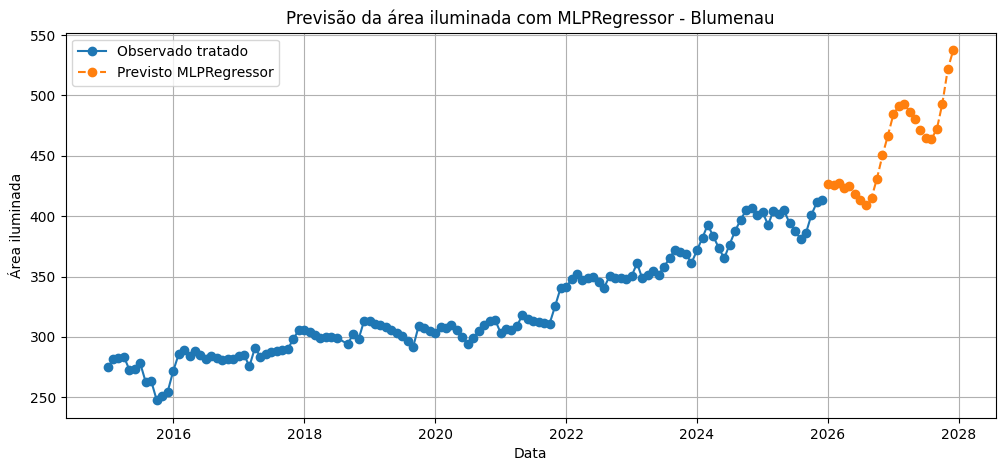

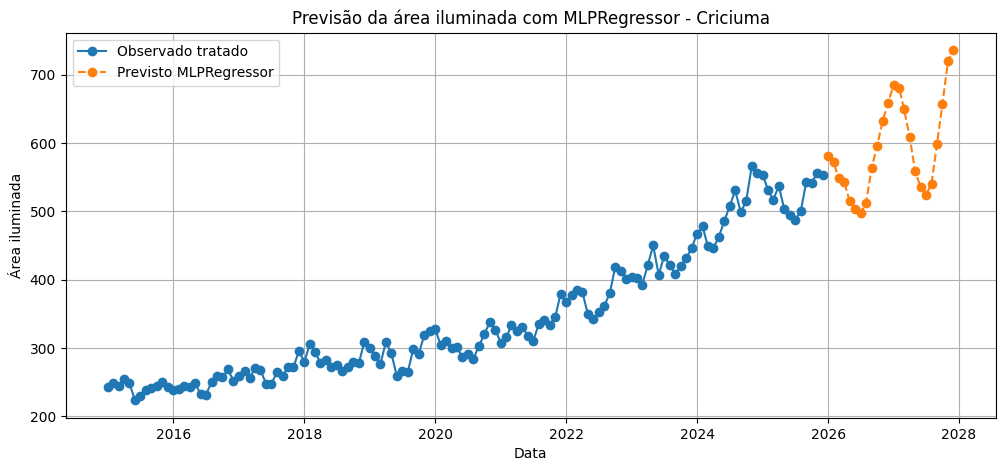

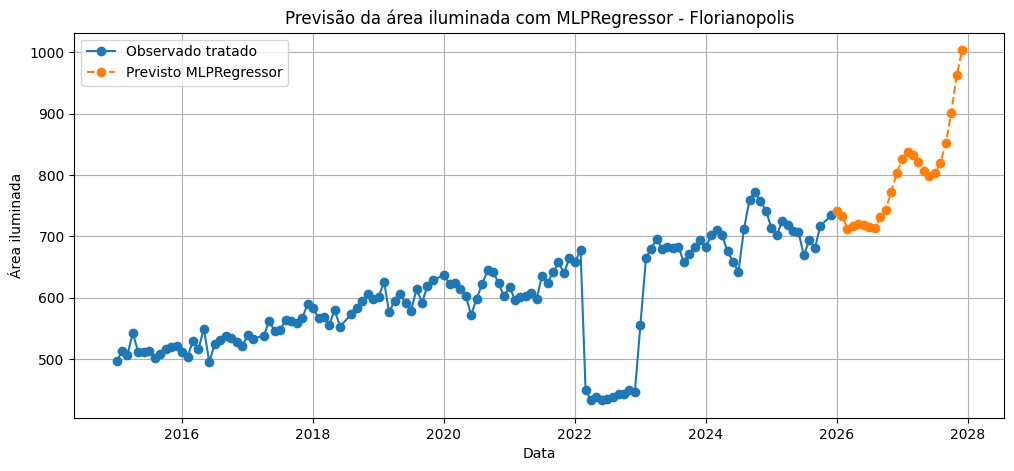

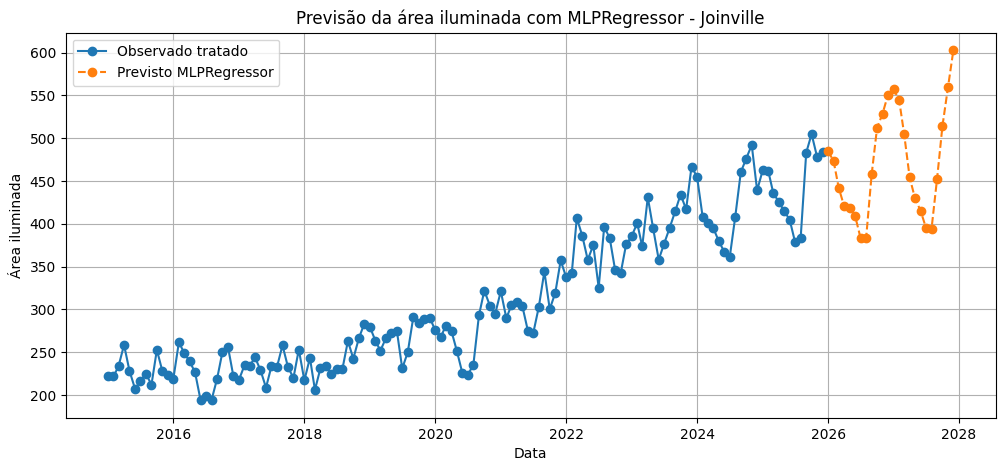

In [33]:
for regiao in sorted(tabela_metricas_modelo["regiao"].unique()):
    dados_observados = tabela_metricas_modelo[tabela_metricas_modelo["regiao"] == regiao]
    dados_previstos = tabela_previsoes[tabela_previsoes["regiao"] == regiao]

    if len(dados_previstos) == 0:
        print(f"{regiao}: sem previsão para visualizar.")
        continue

    plt.figure(figsize=(12, 5))
    plt.plot(
        dados_observados["data"],
        dados_observados["area_iluminada_km2"],
        marker="o",
        label="Observado tratado"
    )
    plt.plot(
        dados_previstos["data"],
        dados_previstos["area_iluminada_prevista_km2"],
        marker="o",
        linestyle="--",
        label="Previsto MLPRegressor"
    )

    plt.title(f"Previsão da área iluminada com MLPRegressor - {regiao}")
    plt.xlabel("Data")
    plt.ylabel("Área iluminada")
    plt.legend()
    plt.grid(True)
    plt.show()

## 13. Validação comparando com o último ano

In [34]:
# Validação feita para medir a acurácia do modelo, treinando com dados até o penúltimo ano,
# prevendo o último ano e comparando com os valores observados.

linhas_validacao = []
linhas_previsoes_teste = []

for regiao in sorted(tabela_metricas_modelo["regiao"].unique()):
    dados_regiao = tabela_metricas_modelo[tabela_metricas_modelo["regiao"] == regiao].copy()
    dados_regiao = dados_regiao.sort_values("data")

    ultimo_ano = dados_regiao["ano"].max()
    dados_treino = dados_regiao[dados_regiao["ano"] < ultimo_ano].copy()
    dados_teste = dados_regiao[dados_regiao["ano"] == ultimo_ano].copy().sort_values("data")

    if len(dados_treino) < 12 or len(dados_teste) == 0:
        print(f"{regiao}: dados insuficientes para validação simples.")
        continue

    modelo_validacao, tabela_teste_prevista = prever_area_iluminada_regiao(
        dados_treino,
        quantidade_meses_futuros=len(dados_teste)
    )

    if modelo_validacao is None or len(tabela_teste_prevista) == 0:
        print(f"{regiao}: não foi possível validar o MLPRegressor.")
        continue

    quantidade_comparacao = min(len(dados_teste), len(tabela_teste_prevista))
    dados_teste_comparacao = dados_teste.iloc[:quantidade_comparacao].copy()
    tabela_teste_prevista = tabela_teste_prevista.iloc[:quantidade_comparacao].copy()

    area_observada = dados_teste_comparacao["area_iluminada_km2"].values
    area_prevista = tabela_teste_prevista["area_iluminada_prevista_km2"].values

    erro_medio_absoluto = mean_absolute_error(area_observada, area_prevista)
    raiz_erro_quadratico_medio = mean_squared_error(area_observada, area_prevista) ** 0.5

    linhas_validacao.append({
        "regiao": regiao,
        "ano_teste": ultimo_ano,
        "erro_medio_absoluto": erro_medio_absoluto,
        "raiz_erro_quadratico_medio": raiz_erro_quadratico_medio
    })

    tabela_teste_prevista["regiao"] = regiao
    tabela_teste_prevista["area_observada_km2"] = area_observada
    linhas_previsoes_teste.append(tabela_teste_prevista)


tabela_validacao = pd.DataFrame(linhas_validacao)

area_media_por_regiao = (
    tabela_metricas_modelo
    .groupby("regiao")["area_iluminada_km2"]
    .mean()
    .reset_index()
    .rename(columns={"area_iluminada_km2": "area_media_iluminada_km2"})
)

tabela_validacao_interpretada = tabela_validacao.merge(
    area_media_por_regiao,
    on="regiao",
    how="left"
)

tabela_validacao_interpretada["erro_medio_percentual"] = (
    tabela_validacao_interpretada["erro_medio_absoluto"] /
    tabela_validacao_interpretada["area_media_iluminada_km2"]
) * 100

tabela_validacao_interpretada["erro_rmse_percentual"] = (
    tabela_validacao_interpretada["raiz_erro_quadratico_medio"] /
    tabela_validacao_interpretada["area_media_iluminada_km2"]
) * 100

display(tabela_validacao_interpretada)

salvar_arquivo_csv(tabela_validacao_interpretada, "validacao_mlpregressor_interpretada")

,regiao,ano_teste,erro_medio_absoluto,raiz_erro_quadratico_medio,area_media_iluminada_km2,erro_medio_percentual,erro_rmse_percentual
0,Blumenau,2025,50.915103,56.182327,323.735737,15.727366,17.354379
1,Criciuma,2025,121.983408,130.317776,344.389678,35.420170,37.840210
2,Florianopolis,2025,45.539162,52.995510,597.663865,7.619527,8.867110
3,Joinville,2025,27.664677,43.854050,309.833167,8.928895,14.154085


## 14. Funções auxiliares e configurações espaciais

In [35]:
def obter_ultima_imagem_regiao(regiao):
    arquivos_regiao = tabela_arquivos[tabela_arquivos["regiao"] == regiao].sort_values("data")
    return arquivos_regiao.iloc[-1]

COLUNAS_ENTRADA_ESPACIAL = [
    "luz_log",
    "media_luz_vizinhanca",
    "distancia_ate_area_iluminada",
    "linha_normalizada",
    "coluna_normalizada"
]

## 15. Criação das features espaciais por pixel

In [36]:
# Retorna a média de luz ao redor de um pixel
def calcular_media_vizinhanca(imagem_luzes, tamanho_janela=5):
    imagem_valida = np.isfinite(imagem_luzes)
    imagem_sem_nan = np.nan_to_num(imagem_luzes, nan=0.0, posinf=0.0, neginf=0.0)

    soma_media = uniform_filter(imagem_sem_nan, size=tamanho_janela, mode="nearest")
    contagem_media = uniform_filter(imagem_valida.astype(float), size=tamanho_janela, mode="nearest")

    media_vizinhanca = np.divide(
        soma_media,
        contagem_media,
        out=np.zeros_like(soma_media, dtype=float),
        where=contagem_media > 0
    )

    return media_vizinhanca

# Gera as features para cada pixel
# 1. A luz no pixel
# 2. Luz vizinha
# 3. Distância de uma área ilumindada
# 4. Posição na imagem, normalizada entre 0 e 1 (linha e coluna)
def criar_camadas_features_espaciais(imagem_luzes, mascara_area_iluminada):
    quantidade_linhas, quantidade_colunas = imagem_luzes.shape

    imagem_sem_nan = np.nan_to_num(imagem_luzes, nan=0.0, posinf=0.0, neginf=0.0)
    imagem_sem_nan = np.clip(imagem_sem_nan, 0, None)

    luz_log = np.log1p(imagem_sem_nan)
    media_luz_vizinhanca = calcular_media_vizinhanca(luz_log, tamanho_janela=5)

    # Para pixels apagados, mede a distância até a área iluminada mais próxima.
    distancia_ate_area_iluminada = distance_transform_edt(~mascara_area_iluminada)

    indices_linha, indices_coluna = np.indices(imagem_luzes.shape)
    linha_normalizada = indices_linha / max(quantidade_linhas - 1, 1)
    coluna_normalizada = indices_coluna / max(quantidade_colunas - 1, 1)

    return {
        "luz_log": luz_log,
        "media_luz_vizinhanca": media_luz_vizinhanca,
        "distancia_ate_area_iluminada": distancia_ate_area_iluminada,
        "linha_normalizada": linha_normalizada,
        "coluna_normalizada": coluna_normalizada
    }

# Gera uma tabela com informações espaciais para cada pixel 
def criar_tabela_features_pixels(camadas_features, indices_pixels):
    return pd.DataFrame({
        nome_coluna: camadas_features[nome_coluna].ravel()[indices_pixels]
        for nome_coluna in COLUNAS_ENTRADA_ESPACIAL
    })


## 16. Criação das amostras de treino espacial

In [37]:
# Cria dataset comparando uma imagem com a imagem do ano seguinte
# Verifica se o pixel que estava apagado acendeu
def criar_amostras_previsao_espacial_regiao(
    regiao,
    max_amostras_por_classe=5000,
    seed=42):
    gerador_aleatorio = np.random.default_rng(seed)

    arquivos_regiao = (
        tabela_arquivos[tabela_arquivos["regiao"] == regiao]
        .sort_values("data")
        .copy()
    )

    arquivos_por_ano_mes = {
        (linha.ano, linha.mes): linha
        for linha in arquivos_regiao.itertuples()
    }

    tabelas_features = []
    listas_alvo = []
    pares_usados = 0
    pares_ignorados = 0

    for linha_atual in arquivos_regiao.itertuples():
        chave_futura = (linha_atual.ano + 1, linha_atual.mes)

        if chave_futura not in arquivos_por_ano_mes:
            continue

        linha_futura = arquivos_por_ano_mes[chave_futura]

        imagem_atual, _, _ = ler_imagem_luzes(linha_atual.caminho_tif)
        imagem_futura, _, _ = ler_imagem_luzes(linha_futura.caminho_tif)

        if imagem_atual.shape != imagem_futura.shape:
            pares_ignorados += 1
            continue

        threshold_luz = thresholdes_por_regiao[regiao]
        mascara_atual = criar_mascara_area_iluminada(imagem_atual, threshold_luz)
        mascara_futura = criar_mascara_area_iluminada(imagem_futura, threshold_luz)

        mascara_valida = np.isfinite(imagem_atual) & np.isfinite(imagem_futura)
        mascara_candidatos = mascara_valida & (~mascara_atual) # ~ Inverte a máscara (True <-> False)

        # O alvo do modelo espacial é a expansão real observada no ano seguinte
        mascara_expansao_real = mascara_candidatos & mascara_futura

        indices_positivos = np.flatnonzero(mascara_expansao_real)
        indices_negativos = np.flatnonzero(mascara_candidatos & (~mascara_futura))

        if len(indices_positivos) == 0 or len(indices_negativos) == 0:
            continue

        quantidade_positivos = min(len(indices_positivos), max_amostras_por_classe)
        quantidade_negativos = min(len(indices_negativos), max_amostras_por_classe, quantidade_positivos * 2)

        indices_positivos = gerador_aleatorio.choice(
            indices_positivos,
            size=quantidade_positivos,
            replace=False
        )
        indices_negativos = gerador_aleatorio.choice(
            indices_negativos,
            size=quantidade_negativos,
            replace=False
        )

        camadas_features = criar_camadas_features_espaciais(imagem_atual, mascara_atual)

        tabela_features_positivos = criar_tabela_features_pixels(camadas_features, indices_positivos)
        tabela_features_negativos = criar_tabela_features_pixels(camadas_features, indices_negativos)

        tabelas_features.append(pd.concat([
            tabela_features_positivos,
            tabela_features_negativos
        ], ignore_index=True))

        listas_alvo.append(np.concatenate([
            np.ones(len(tabela_features_positivos), dtype=int),
            np.zeros(len(tabela_features_negativos), dtype=int)
        ]))

        pares_usados += 1

    if len(tabelas_features) == 0:
        return pd.DataFrame(), np.array([]), pares_usados, pares_ignorados

    tabela_features = pd.concat(tabelas_features, ignore_index=True)
    alvo_expansao = np.concatenate(listas_alvo)

    return tabela_features, alvo_expansao, pares_usados, pares_ignorados


## 17. Treinamento do RandomForest espacial

In [38]:
# Faz o treinamento do modelo da região
def treinar_modelo_espacial_regiao(regiao):
    tabela_features, alvo_expansao, pares_usados, pares_ignorados = criar_amostras_previsao_espacial_regiao(regiao)

    if len(tabela_features) < 50 or len(np.unique(alvo_expansao)) < 2:
        print(f"{regiao}: dados insuficientes para treinar o modelo espacial.")
        return None

    modelo_espacial = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1
    )

    modelo_espacial.fit(tabela_features[COLUNAS_ENTRADA_ESPACIAL], alvo_expansao)

    if MOSTRAR_DETALHES:
        print(f"{regiao}: modelo espacial treinado com {len(tabela_features)} pixels amostrados.")
        print(f"{regiao}: pares temporais usados = {pares_usados}; pares ignorados por formato diferente = {pares_ignorados}")

    return modelo_espacial


## 18. Combinação da previsão temporal com a previsão espacial

Esta parte usa a área futura prevista pelo `MLPRegressor` temporal e escolhe, com o modelo espacial, onde essa expansão deve ocorrer.

In [39]:
# Fallback simples caso o modelo espacial não consiga ser treinado
# Ele expande a máscara atual por dilatação até chegar perto da quantidade de pixels prevista
def expandir_mascara_ate_area_prevista(mascara_atual, pixels_previstos, max_iteracoes=1000):
    mascara_prevista = mascara_atual.copy()

    for _ in range(max_iteracoes):
        if int(mascara_prevista.sum()) >= pixels_previstos:
            break

        nova_mascara = binary_dilation(mascara_prevista)

        if int(nova_mascara.sum()) == int(mascara_prevista.sum()):
            break

        mascara_prevista = nova_mascara

    return mascara_prevista


# Utiliza o MLPRegressor para encontrar o valor da área prevista em km²
# Combina com o RandomForestClassifier espacial para encontrar os pixels mais prováveis de serem expandidos
def prever_expansao_espacial_regiao(regiao, meses_a_frente=12):
    ultimo_arquivo = obter_ultima_imagem_regiao(regiao)

    imagem_luzes, transformacao_espacial, sistema_referencia = ler_imagem_luzes(ultimo_arquivo.caminho_tif)
    imagem_visual = normalizar_para_visualizacao(imagem_luzes)

    threshold_luz = thresholdes_por_regiao[regiao]
    mascara_atual = criar_mascara_area_iluminada(imagem_luzes, threshold_luz)

    area_pixel_km2 = calcular_area_pixel_km2(transformacao_espacial, sistema_referencia)

    previsoes_regiao = tabela_previsoes[tabela_previsoes["regiao"] == regiao].sort_values("data")
    previsao_escolhida = previsoes_regiao.iloc[min(meses_a_frente - 1, len(previsoes_regiao) - 1)]

    area_prevista_km2 = float(previsao_escolhida["area_iluminada_prevista_km2"])
    pixels_atuais = int(mascara_atual.sum())
    pixels_validos = int(np.isfinite(imagem_luzes).sum())

    if area_pixel_km2 > 0:
        pixels_previstos = int(area_prevista_km2 / area_pixel_km2)
    else:
        pixels_previstos = pixels_atuais

    # Trava física simples: não permite prever menos que a área atual nem mais pixels que a área válida da imagem
    pixels_previstos = np.clip(pixels_previstos, pixels_atuais, pixels_validos)
    pixels_expansao = max(int(pixels_previstos) - pixels_atuais, 0)

    probabilidade_expansao = np.zeros(imagem_luzes.shape, dtype=float)
    mascara_expansao = np.zeros(imagem_luzes.shape, dtype=bool)

    modelo_espacial = treinar_modelo_espacial_regiao(regiao)

    if modelo_espacial is None:
        mascara_prevista = expandir_mascara_ate_area_prevista(mascara_atual, int(pixels_previstos))
        mascara_expansao = mascara_prevista & (~mascara_atual)
        metodo_espacial = "Fallback por dilatação morfológica"
    else:
        camadas_features = criar_camadas_features_espaciais(imagem_luzes, mascara_atual)
        mascara_candidatos = np.isfinite(imagem_luzes) & (~mascara_atual)

        indices_candidatos = np.flatnonzero(mascara_candidatos)

        if len(indices_candidatos) == 0:
            mascara_prevista = mascara_atual.copy()
            metodo_espacial = "Sem pixels candidatos"
        else:
            tabela_candidatos = criar_tabela_features_pixels(camadas_features, indices_candidatos)

            probabilidades = modelo_espacial.predict_proba(
                tabela_candidatos[COLUNAS_ENTRADA_ESPACIAL]
            )[:, 1]

            probabilidade_expansao.flat[indices_candidatos] = probabilidades

            quantidade_pixels_selecionados = min(pixels_expansao, len(indices_candidatos))

            if quantidade_pixels_selecionados > 0:
                posicoes_ordenadas = np.argsort(probabilidades)[::-1]
                indices_expansao = indices_candidatos[posicoes_ordenadas[:quantidade_pixels_selecionados]]
                mascara_expansao.flat[indices_expansao] = True

            mascara_prevista = mascara_atual | mascara_expansao
            metodo_espacial = "RandomForestClassifier por pixel"

    return {
        "regiao": regiao,
        "imagem_visual": imagem_visual,
        "mascara_atual": mascara_atual,
        "mascara_prevista": mascara_prevista,
        "mascara_expansao": mascara_expansao,
        "probabilidade_expansao": probabilidade_expansao,
        "data_prevista": previsao_escolhida["data"],
        "area_prevista_km2": area_prevista_km2,
        "pixels_atuais": pixels_atuais,
        "pixels_previstos": int(mascara_prevista.sum()),
        "metodo_espacial": metodo_espacial
    }


## 19 Visualização do mapa de expansão prevista

C:\Users\thomh\AppData\Local\Temp\ipykernel_10540\2405432127.py:59: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_area_iluminada = remove_small_objects(mascara_area_iluminada, min_size=9)
C:\Users\thomh\AppData\Local\Temp\ipykernel_10540\2405432127.py:60: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  

Região: Blumenau
Modelo temporal usado: MLPRegressor
Modelo espacial usado: RandomForestClassifier por pixel
Data prevista: 2026-12-01
Área prevista: 466.62 km²
Pixels iluminados atuais: 1759
Pixels iluminados previstos: 1985
Pixels de expansão: 226


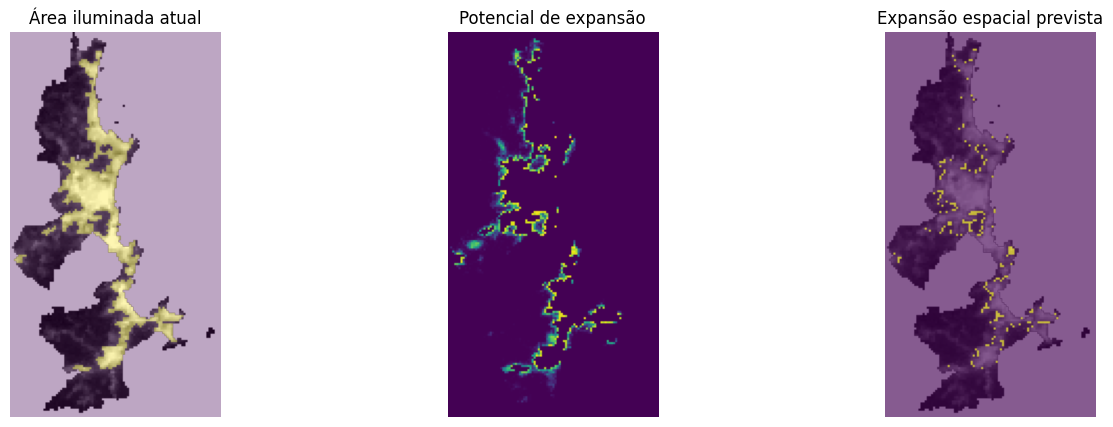

In [40]:
def mostrar_mapa_expansao_prevista(regiao, meses_a_frente=12):
    resultado_espacial = prever_expansao_espacial_regiao(regiao, meses_a_frente=meses_a_frente)

    print("Região:", resultado_espacial["regiao"])
    print("Modelo temporal usado: MLPRegressor")
    print("Modelo espacial usado:", resultado_espacial["metodo_espacial"])
    print("Data prevista:", resultado_espacial["data_prevista"].date())
    print("Área prevista:", round(resultado_espacial["area_prevista_km2"], 2), "km²")
    print("Pixels iluminados atuais:", resultado_espacial["pixels_atuais"])
    print("Pixels iluminados previstos:", resultado_espacial["pixels_previstos"])
    print("Pixels de expansão:", int(resultado_espacial["mascara_expansao"].sum()))

    figura, eixos = plt.subplots(1, 3, figsize=(16, 5))

    eixos[0].imshow(resultado_espacial["imagem_visual"], cmap="gray")
    eixos[0].imshow(resultado_espacial["mascara_atual"], alpha=0.35)
    eixos[0].set_title("Área iluminada atual")

    eixos[1].imshow(resultado_espacial["probabilidade_expansao"])
    eixos[1].set_title("Potencial de expansão")

    eixos[2].imshow(resultado_espacial["imagem_visual"], cmap="gray")
    eixos[2].imshow(resultado_espacial["mascara_expansao"], alpha=0.65)
    eixos[2].set_title("Expansão espacial prevista")

    for eixo in eixos:
        eixo.axis("off")

    plt.show()

    return resultado_espacial


REGIAO_ESCOLHIDA = sorted(tabela_metricas_modelo["regiao"].unique())[0]
resultado_expansao_espacial = mostrar_mapa_expansao_prevista(REGIAO_ESCOLHIDA, meses_a_frente=12)


## 20. Visualização dos modelos

Florianopolis: o modelo temporal agora é um MLPRegressor.
Redes neurais MLP não possuem feature_importances_ como RandomForest.
Para avaliar o modelo temporal, use o gráfico observado x previsto e a tabela de validação.


C:\Users\thomh\AppData\Local\Temp\ipykernel_10540\2405432127.py:59: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_area_iluminada = remove_small_objects(mascara_area_iluminada, min_size=9)
C:\Users\thomh\AppData\Local\Temp\ipykernel_10540\2405432127.py:60: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  

,feature,importancia
0,luz_log,0.424621
1,media_luz_vizinhanca,0.271397
2,distancia_ate_area_iluminada,0.172762
3,linha_normalizada,0.066267
4,coluna_normalizada,0.064952


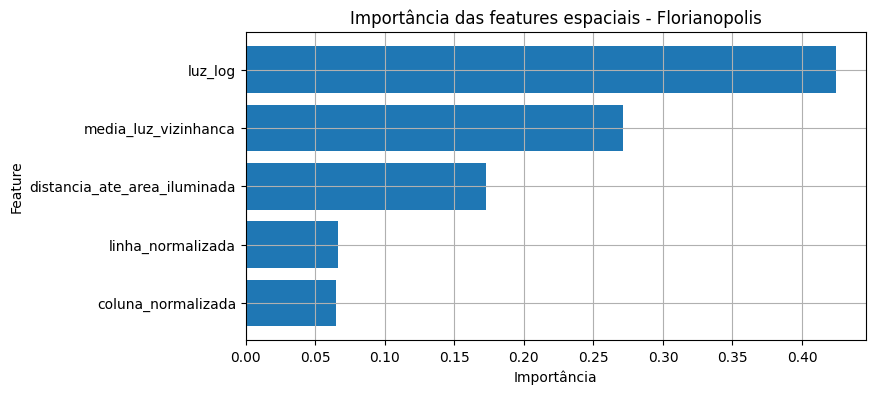

In [41]:
def visualizar_importancia_modelo_temporal(regiao):
    modelo_temporal = modelos_por_regiao.get(regiao)

    if modelo_temporal is None:
        print(f"{regiao}: modelo temporal não encontrado.")
        return

    print(f"{regiao}: o modelo temporal agora é um MLPRegressor.")
    print("Redes neurais MLP não possuem feature_importances_ como RandomForest.")
    print("Para avaliar o modelo temporal, use o gráfico observado x previsto e a tabela de validação.")


def visualizar_importancia_modelo_espacial(regiao):
    modelo_espacial = treinar_modelo_espacial_regiao(regiao)

    if modelo_espacial is None:
        print(f"{regiao}: modelo espacial não encontrado.")
        return

    tabela_importancia = pd.DataFrame({
        "feature": COLUNAS_ENTRADA_ESPACIAL,
        "importancia": modelo_espacial.feature_importances_
    }).sort_values("importancia", ascending=True)

    display(tabela_importancia.sort_values("importancia", ascending=False))

    plt.figure(figsize=(8, 4))
    plt.barh(tabela_importancia["feature"], tabela_importancia["importancia"])
    plt.title(f"Importância das features espaciais - {regiao}")
    plt.xlabel("Importância")
    plt.ylabel("Feature")
    plt.grid(True)
    plt.show()


visualizar_importancia_modelo_temporal("Florianopolis")
visualizar_importancia_modelo_espacial("Florianopolis")


## 21. Visualização de uma árvore espacial

A árvore temporal deixa de existir porque a previsão temporal usa uma rede neural MLP. A árvore abaixo continua sendo do modelo espacial RandomForestClassifier.

Florianopolis: o modelo temporal agora é um MLPRegressor.
MLPRegressor é uma rede neural e não possui árvores para visualizar.


C:\Users\thomh\AppData\Local\Temp\ipykernel_10540\2405432127.py:59: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_area_iluminada = remove_small_objects(mascara_area_iluminada, min_size=9)
C:\Users\thomh\AppData\Local\Temp\ipykernel_10540\2405432127.py:60: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  

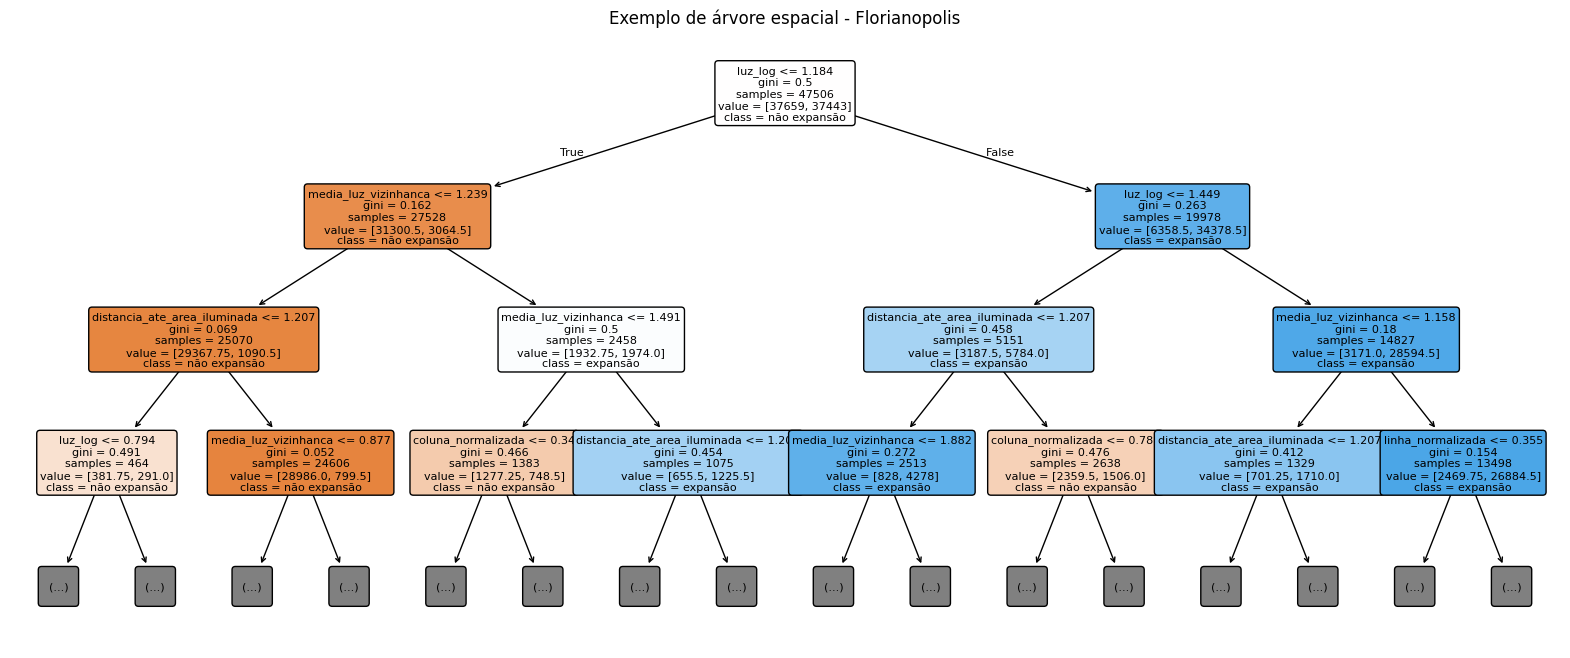

In [42]:
def visualizar_arvore_temporal(regiao, indice_arvore=0, profundidade=3):
    modelo_temporal = modelos_por_regiao.get(regiao)

    if modelo_temporal is None:
        print(f"{regiao}: modelo temporal não encontrado.")
        return

    print(f"{regiao}: o modelo temporal agora é um MLPRegressor.")
    print("MLPRegressor é uma rede neural e não possui árvores para visualizar.")


def visualizar_arvore_espacial(regiao, indice_arvore=0, profundidade=3):
    modelo_espacial = treinar_modelo_espacial_regiao(regiao)

    if modelo_espacial is None:
        print(f"{regiao}: modelo espacial não encontrado.")
        return

    arvore = modelo_espacial.estimators_[indice_arvore]

    plt.figure(figsize=(20, 8))
    plot_tree(
        arvore,
        feature_names=COLUNAS_ENTRADA_ESPACIAL,
        class_names=["não expansão", "expansão"],
        filled=True,
        rounded=True,
        max_depth=profundidade,
        fontsize=8
    )
    plt.title(f"Exemplo de árvore espacial - {regiao}")
    plt.show()


visualizar_arvore_temporal("Florianopolis")
visualizar_arvore_espacial("Florianopolis")
